Bootstrap, calcular 𝜶 y, el ajuste cuadrático-- mtcars

Datos mtcars:
    mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  carb
0  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4     4
1  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4     4
2  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4     1
3  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3     1
4  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3     2
Valor óptimo de α: 0.0664

Interpretación:
Para minimizar la varianza combinada, la proporción óptima es 6.64% para X (hp) y 93.36% para Y (mpg)

Resultados Bootstrap (n=1000):
Media α: 0.0684
Intervalo 95%: (0.0479, 0.0956)


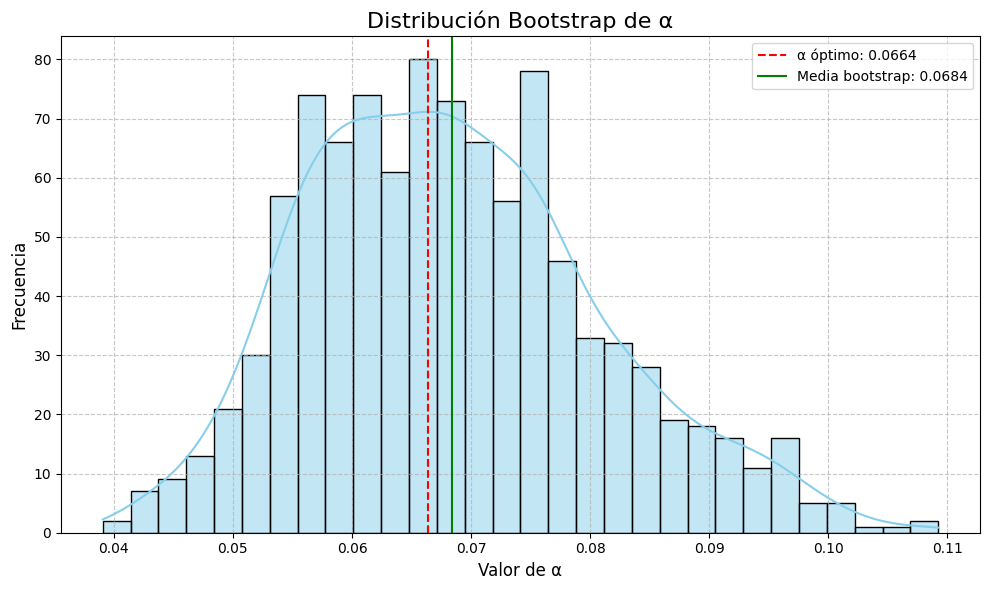


Ajuste cuadrático (datos originales):
β0 = 40.4091, β1 = -0.2133, β2 = 0.0004
R² = 0.7561

Intervalos Bootstrap 95% para coeficientes:
β0 (Intercepto): (34.9123, 47.4002)
β1 (hp): (-0.3110, -0.1512)
β2 (hp²): (0.0003, 0.0007)
R²: (0.6027, 0.8768)


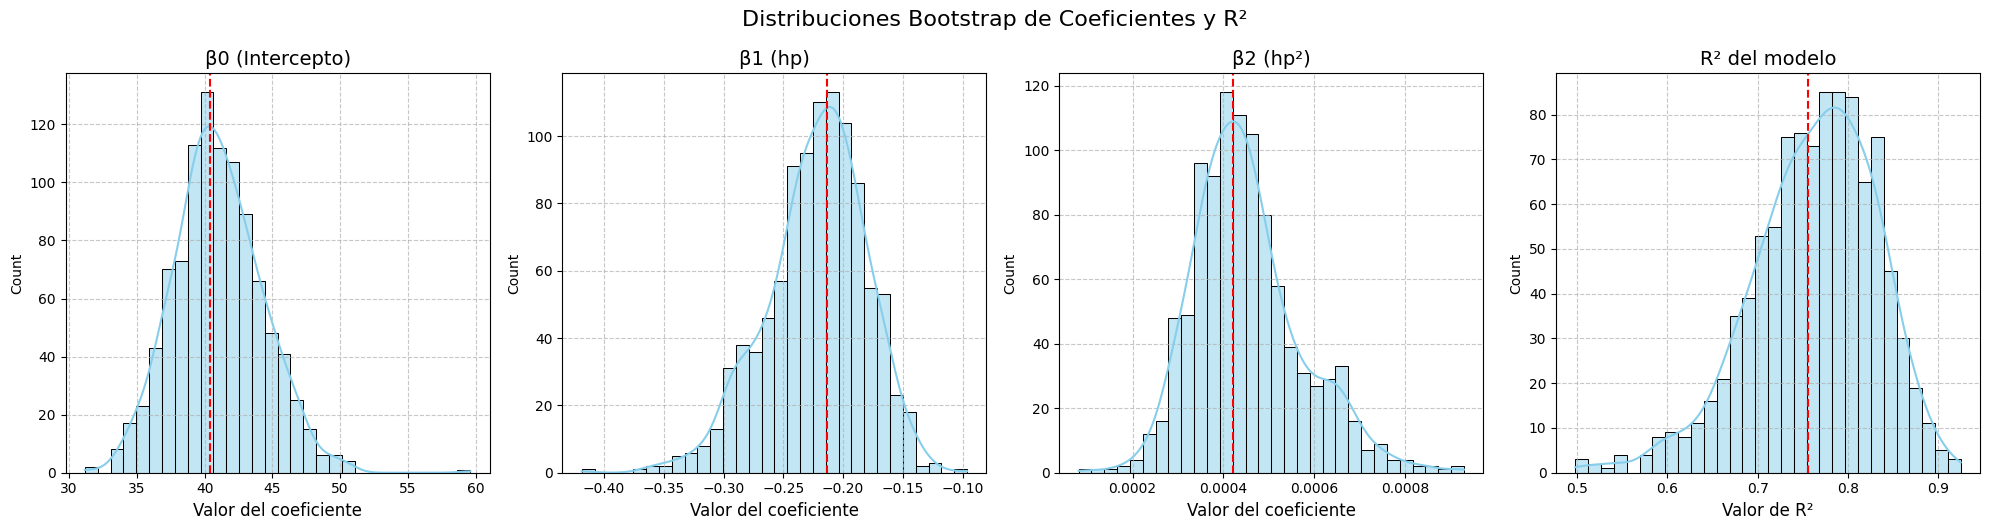

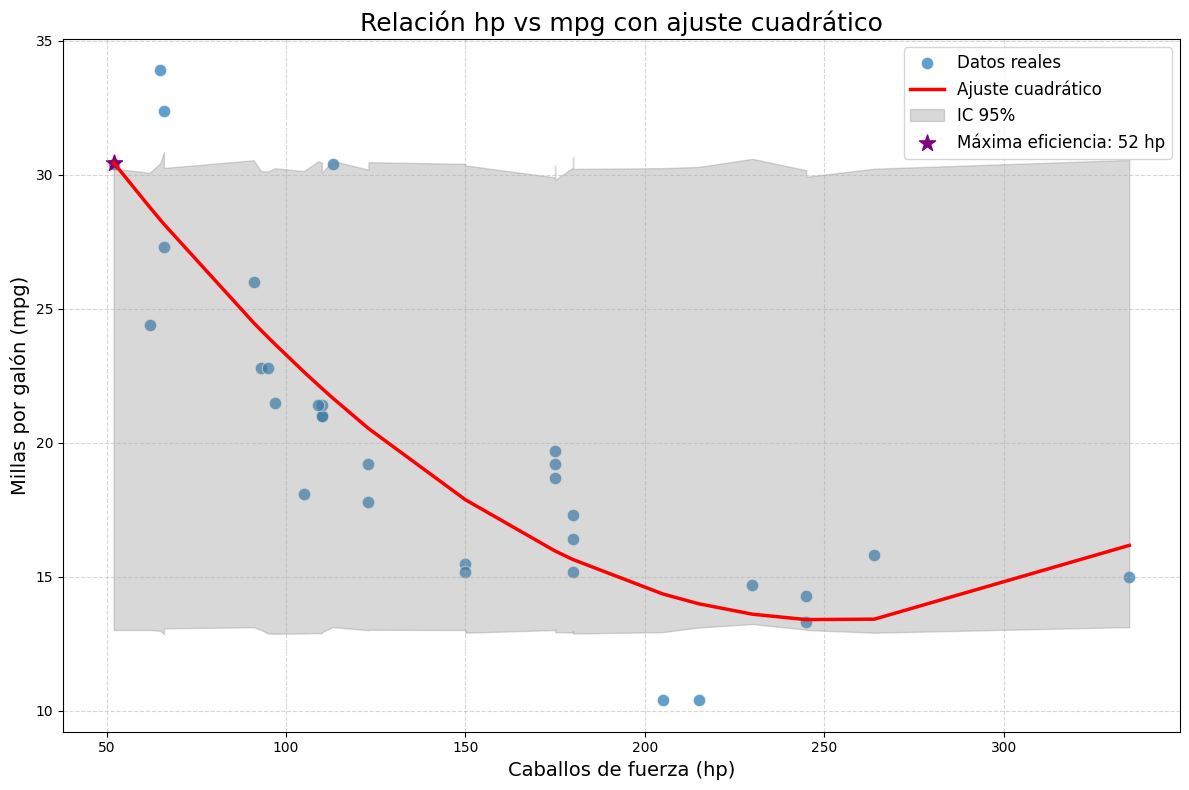

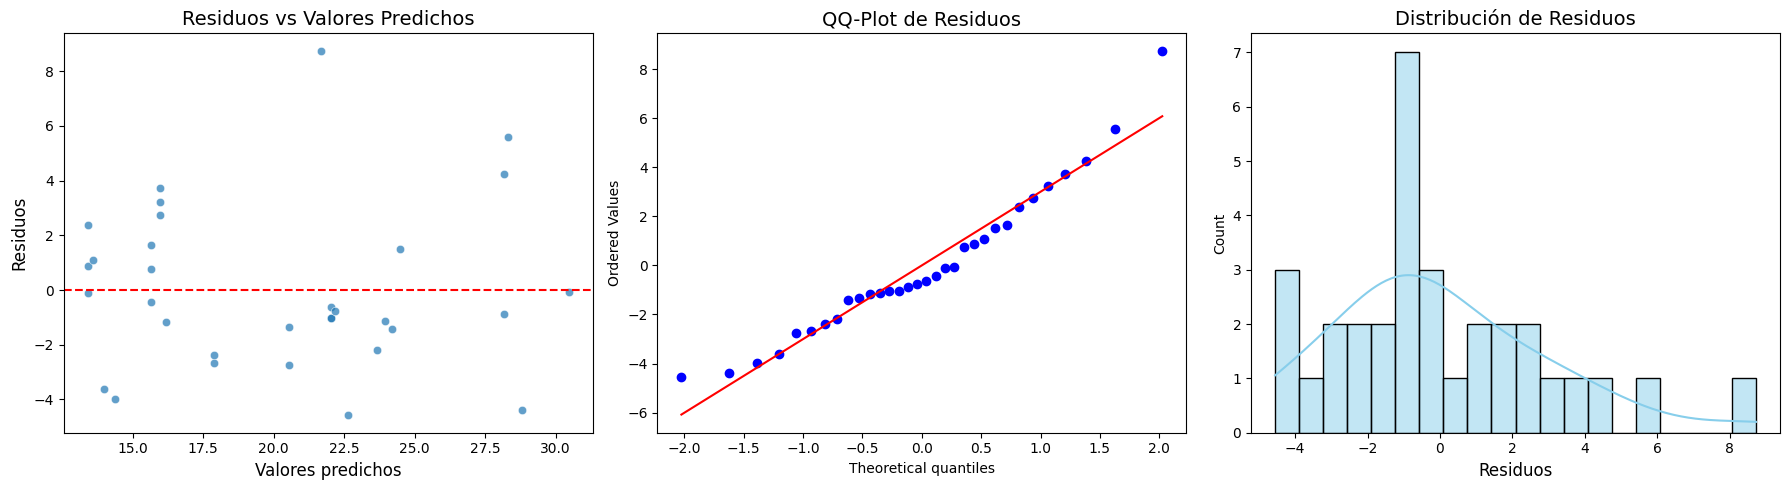

In [ ]:

!pip install openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.metrics import r2_score
import scipy.stats as stats

mtcars = pd.read_excel('mtcars.xlsx', sheet_name='Sheet1')
print("Datos mtcars:")
print(mtcars.head())



def calcular_alpha(x, y):
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    cov_xy = np.cov(x, y, ddof=1)[0, 1]

    numerador = var_y - cov_xy
    denominador = var_x - 2*cov_xy + var_y
    return numerador / denominador

# Seleccionar variables
x = mtcars['hp'].values
y = mtcars['mpg'].values

alpha_opt = calcular_alpha(x, y)
print(f"Valor óptimo de α: {alpha_opt:.4f}")

# Interpretación
print("\nInterpretación:")
print(f"Para minimizar la varianza combinada, la proporción óptima es {alpha_opt:.2%} para X (hp) y {1-alpha_opt:.2%} para Y (mpg)")

np.random.seed(42)
n_bootstraps = 1000
alpha_bootstraps = []

for _ in range(n_bootstraps):
    x_resample, y_resample = resample(x, y)
    alpha_bs = calcular_alpha(x_resample, y_resample)
    alpha_bootstraps.append(alpha_bs)

# Convertir a array
alpha_bootstraps = np.array(alpha_bootstraps)

# Estadísticas
mean_alpha = np.mean(alpha_bootstraps)
ci_low = np.percentile(alpha_bootstraps, 2.5)
ci_high = np.percentile(alpha_bootstraps, 97.5)

print(f"\nResultados Bootstrap (n={n_bootstraps}):")
print(f"Media α: {mean_alpha:.4f}")
print(f"Intervalo 95%: ({ci_low:.4f}, {ci_high:.4f})")

# Gráfico de distribución
plt.figure(figsize=(10, 6))
sns.histplot(alpha_bootstraps, kde=True, bins=30, color='skyblue')
plt.axvline(alpha_opt, color='r', linestyle='--', label=f'α óptimo: {alpha_opt:.4f}')
plt.axvline(mean_alpha, color='g', linestyle='-', label=f'Media bootstrap: {mean_alpha:.4f}')
plt.title('Distribución Bootstrap de α', fontsize=16)
plt.xlabel('Valor de α', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('alpha_bootstrap.png', dpi=300)
plt.show()

# Función para ajuste cuadrático
def ajuste_cuadratico(x, y):
    X = np.column_stack([np.ones_like(x), x, x**2])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_pred = X @ beta
    r2 = r2_score(y, y_pred)
    return beta, r2, y_pred

# Ajuste con datos originales
beta_original, r2_original, y_pred_orig = ajuste_cuadratico(x, y)
print("\nAjuste cuadrático (datos originales):")
print(f"β0 = {beta_original[0]:.4f}, β1 = {beta_original[1]:.4f}, β2 = {beta_original[2]:.4f}")
print(f"R² = {r2_original:.4f}")

# Bootstrap para coeficientes
betas_boot = []
r2_boot = []
y_pred_boot = []

for _ in range(n_bootstraps):
    idx = np.random.choice(len(x), size=len(x), replace=True)
    x_bs = x[idx]
    y_bs = y[idx]

    beta_bs, r2_bs, y_pred_bs = ajuste_cuadratico(x_bs, y_bs)
    betas_boot.append(beta_bs)
    r2_boot.append(r2_bs)
    y_pred_boot.append(y_pred_bs)

betas_boot = np.array(betas_boot)
r2_boot = np.array(r2_boot)
y_pred_boot = np.array(y_pred_boot)

# Intervalos de confianza
print("\nIntervalos Bootstrap 95% para coeficientes:")
coef_names = ['β0 (Intercepto)', 'β1 (hp)', 'β2 (hp²)']
cis = []
for i in range(3):
    ci_low = np.percentile(betas_boot[:, i], 2.5)
    ci_high = np.percentile(betas_boot[:, i], 97.5)
    cis.append((ci_low, ci_high))
    print(f"{coef_names[i]}: ({ci_low:.4f}, {ci_high:.4f})")

ci_r2 = (np.percentile(r2_boot, 2.5), np.percentile(r2_boot, 97.5))
print(f"R²: ({ci_r2[0]:.4f}, {ci_r2[1]:.4f})")

# Gráfico de coeficientes
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Distribución de coeficientes
for i in range(3):
    sns.histplot(betas_boot[:, i], ax=axes[i], kde=True, bins=30, color='skyblue')
    axes[i].axvline(beta_original[i], color='r', linestyle='--')
    axes[i].set_title(coef_names[i], fontsize=14)
    axes[i].set_xlabel('Valor del coeficiente', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Distribución R²
sns.histplot(r2_boot, ax=axes[3], kde=True, bins=30, color='skyblue')
axes[3].axvline(r2_original, color='r', linestyle='--')
axes[3].set_title('R² del modelo', fontsize=14)
axes[3].set_xlabel('Valor de R²', fontsize=12)
axes[3].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Distribuciones Bootstrap de Coeficientes y R²', fontsize=16, y=1.05)
plt.savefig('coeficientes_bootstrap.png', dpi=300)
plt.show()

# Gráfico del modelo
plt.figure(figsize=(12, 8))
sns.scatterplot(x=x, y=y, s=80, alpha=0.7, label='Datos reales')

# Ordenar para la curva
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]
y_pred_sorted = y_pred_orig[sort_idx]

# Calcular bandas de confianza
y_pred_boot_sorted = np.array([pred[sort_idx] for pred in y_pred_boot])
y_pred_low = np.percentile(y_pred_boot_sorted, 2.5, axis=0)
y_pred_high = np.percentile(y_pred_boot_sorted, 97.5, axis=0)

# Gráfico del modelo
plt.plot(x_sorted, y_pred_sorted, 'r-', linewidth=2.5, label='Ajuste cuadrático')
plt.fill_between(x_sorted, y_pred_low, y_pred_high, color='gray', alpha=0.3, label='IC 95%')

# Punto de máxima eficiencia
max_eff_idx = np.argmax(y_pred_sorted)
max_eff_hp = x_sorted[max_eff_idx]
max_eff_mpg = y_pred_sorted[max_eff_idx]
plt.scatter(max_eff_hp, max_eff_mpg, s=150, c='purple', marker='*', label=f'Máxima eficiencia: {max_eff_hp:.0f} hp')

# Configuración del gráfico
plt.title('Relación hp vs mpg con ajuste cuadrático', fontsize=18)
plt.xlabel('Caballos de fuerza (hp)', fontsize=14)
plt.ylabel('Millas por galón (mpg)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ajuste_cuadratico.png', dpi=300)
plt.show()

# Cálculo de residuos
residuos = y - y_pred_orig

# Gráficos de diagnóstico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuos vs predichos
sns.scatterplot(x=y_pred_orig, y=residuos, ax=axes[0], alpha=0.7)
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_title('Residuos vs Valores Predichos', fontsize=14)
axes[0].set_xlabel('Valores predichos', fontsize=12)
axes[0].set_ylabel('Residuos', fontsize=12)

# QQ-plot
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('QQ-Plot de Residuos', fontsize=14)

# Distribución de residuos
sns.histplot(residuos, kde=True, ax=axes[2], bins=20, color='skyblue')
axes[2].set_title('Distribución de Residuos', fontsize=14)
axes[2].set_xlabel('Residuos', fontsize=12)

plt.tight_layout()
plt.savefig('diagnosticos_residuos.png', dpi=300)
plt.show()



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1.- Considere una validación cruzada en un conjunto de datos simulados.

a) Código en R:
set .seed (1); y=rnorm (100); x=rnorm (100); y=x-2* x^2+ rnorm (100)
adapte este código a Python.

b) En este conjunto de datos, ¿qué es 𝑛 y qué es 𝑝? Escribe el modelo utilizado
para generar los datos en forma de ecuación.

c) Crea un diagrama de dispersión de X contra Y. Comenta lo que encuentres.

d) Establezca una semilla aleatoria y luego calcule los errores LOOCV que
resultan del ajuste de los siguientes cuatro modelos mediante mínimos
cuadrados:
Tenga en cuenta que puede resultarle útil usar la función data.frame()
[pd.DataFrame en python] para crear un único conjunto de datos que contenga
X e Y.

e) Repita el punto (d) usando otra semilla aleatoria e informe sus resultados.
¿Son sus resultados iguales a los del punto (c)? ¿Por qué?

f) ¿Cuál de los modelos en (d) tuvo el menor error LOOCV? ¿Es esto lo que
esperabas? Explica tu respuesta.

g) Comente la significancia estadística de las estimaciones de los coeficientes
resultantes del ajuste de cada uno de los modelos en (d) mediante mínimos
cuadrados. ¿Concuerdan estos resultados con las conclusiones extraídas a
partir de los resultados de la validación cruzada?


[b] Análisis del conjunto de datos:
- n (número de observaciones): 100
- p (número de predictores): 1 (variable x)
Modelo generador: y = x - 2x² + ε, donde ε ~ N(0, 1)


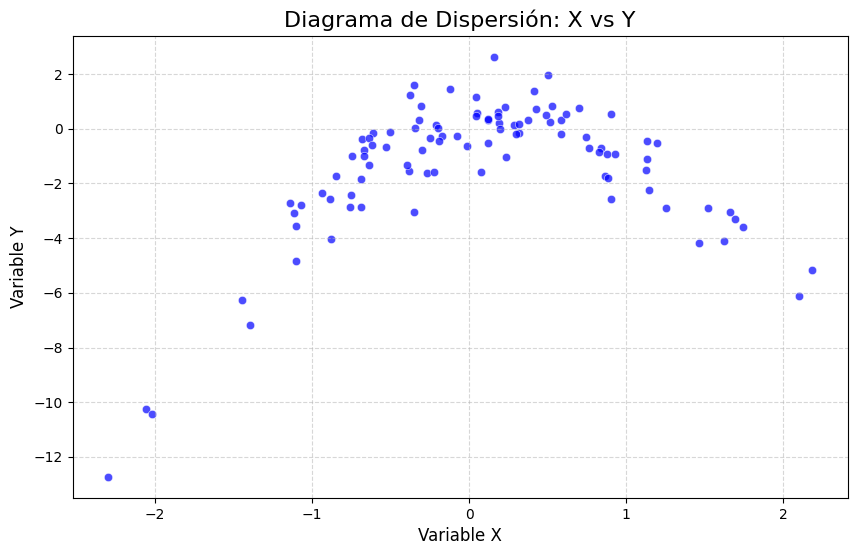


[c] Comentario sobre el diagrama:
Se observa una clara relación cuadrática entre X e Y. Los datos siguen una forma parabólica
cóncava hacia abajo, con un máximo cerca de x = 0. Esto es consistente con el modelo generador
y = x - 2x² + ε. La dispersión de los puntos alrededor de la curva sugiere la presencia de
ruido gaussiano en los datos.

[d] Resultados LOOCV (Semilla 1):
Lineal: MSE = 6.2608
Cuadrático: MSE = 0.9143
Cúbico: MSE = 0.9269
Polinomio grado 4: MSE = 0.8669


/tmp/ipython-input-54-1041249016.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


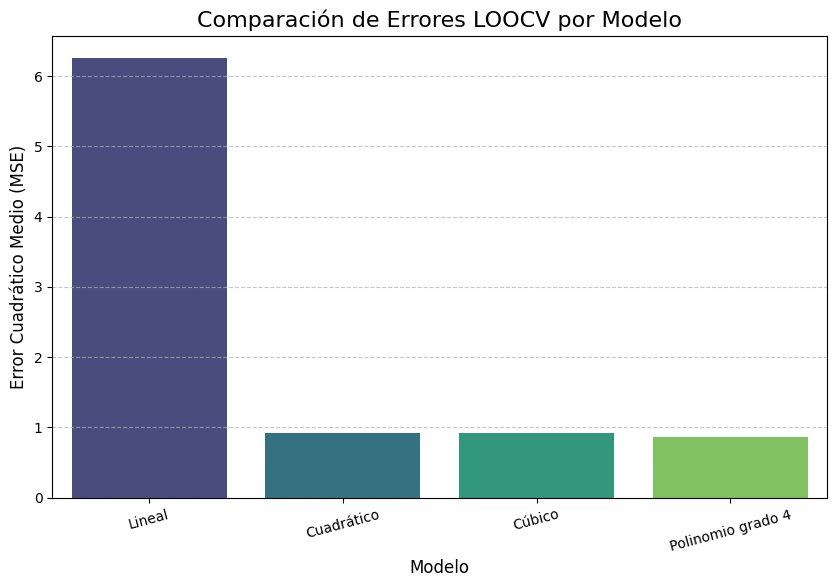


[e] Resultados LOOCV (Semilla 42):
Lineal: MSE = 5.3030
Cuadrático: MSE = 0.9128
Cúbico: MSE = 0.9570
Polinomio grado 4: MSE = 0.9728


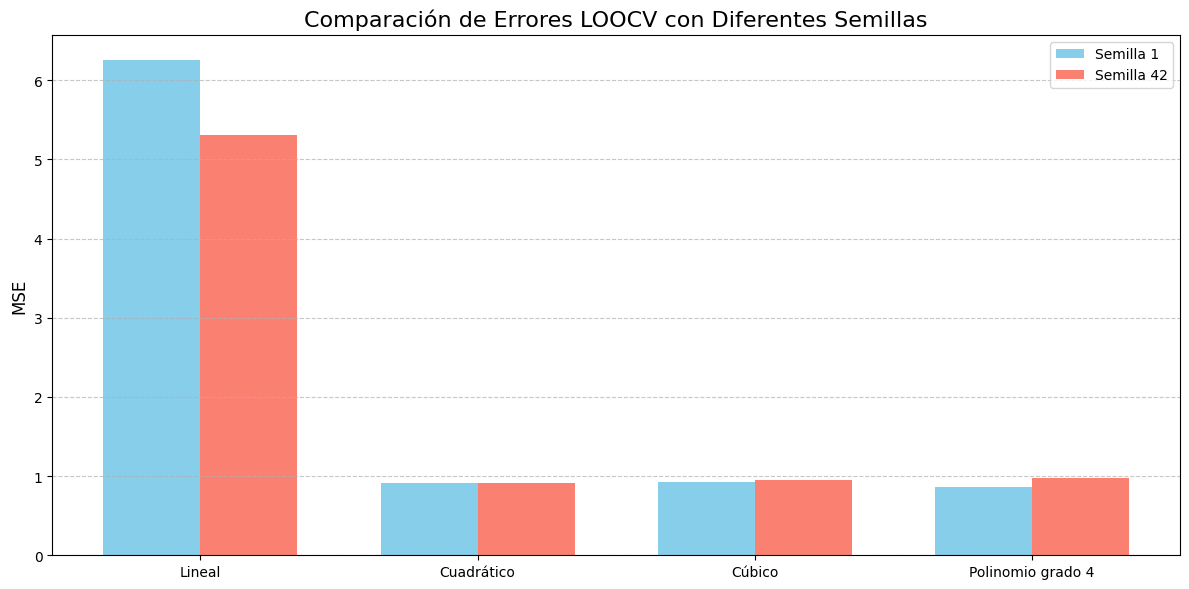


[f] Modelo con menor error LOOCV: Polinomio grado 4 (MSE = 0.8669)
¿Es esto lo que esperabas? Sí, porque el modelo generador es cuadrático (y = x - 2x² + ε)
El modelo cuadrático captura exactamente la relación subyacente en los datos.

[g] Significancia estadística de coeficientes:

Modelo polinómico grado 1:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
1             -1.4131      0.242     -5.849      0.000      -1.893      -0.934
x              0.8610      0.272      3.162      0.002       0.321       1.401


/tmp/ipython-input-54-1041249016.py:201: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(j, coefs[j]*0.8, '*', fontsize=16, ha='center', color='red')
/tmp/ipython-input-54-1041249016.py:201: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(j, coefs[j]*0.8, '*', fontsize=16, ha='center', color='red')



Modelo polinómico grado 2:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
1              0.1350      0.115      1.169      0.245      -0.094       0.364
x              1.0936      0.107     10.229      0.000       0.881       1.306
x^2           -1.9846      0.085    -23.331      0.000      -2.153      -1.816


/tmp/ipython-input-54-1041249016.py:201: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(j, coefs[j]*0.8, '*', fontsize=16, ha='center', color='red')
/tmp/ipython-input-54-1041249016.py:201: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(j, coefs[j]*0.8, '*', fontsize=16, ha='center', color='red')



Modelo polinómico grado 3:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
1              0.1280      0.115      1.111      0.269      -0.101       0.357
x              0.9065      0.187      4.842      0.000       0.535       1.278
x^2           -1.9753      0.085    -23.187      0.000      -2.144      -1.806
x^3            0.0788      0.065      1.216      0.227      -0.050       0.208

Modelo polinómico grado 4:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
1              0.3140      0.136      2.311      0.023       0.044       0.584
x              0.9127      0.183      4.999      0.000       0.550       1.275
x^2           -2.5445      0.248    -10.264      0.000      -3.037      -2.052
x^3            0.0992      0.064      1.556      0.123      -0.027       0.

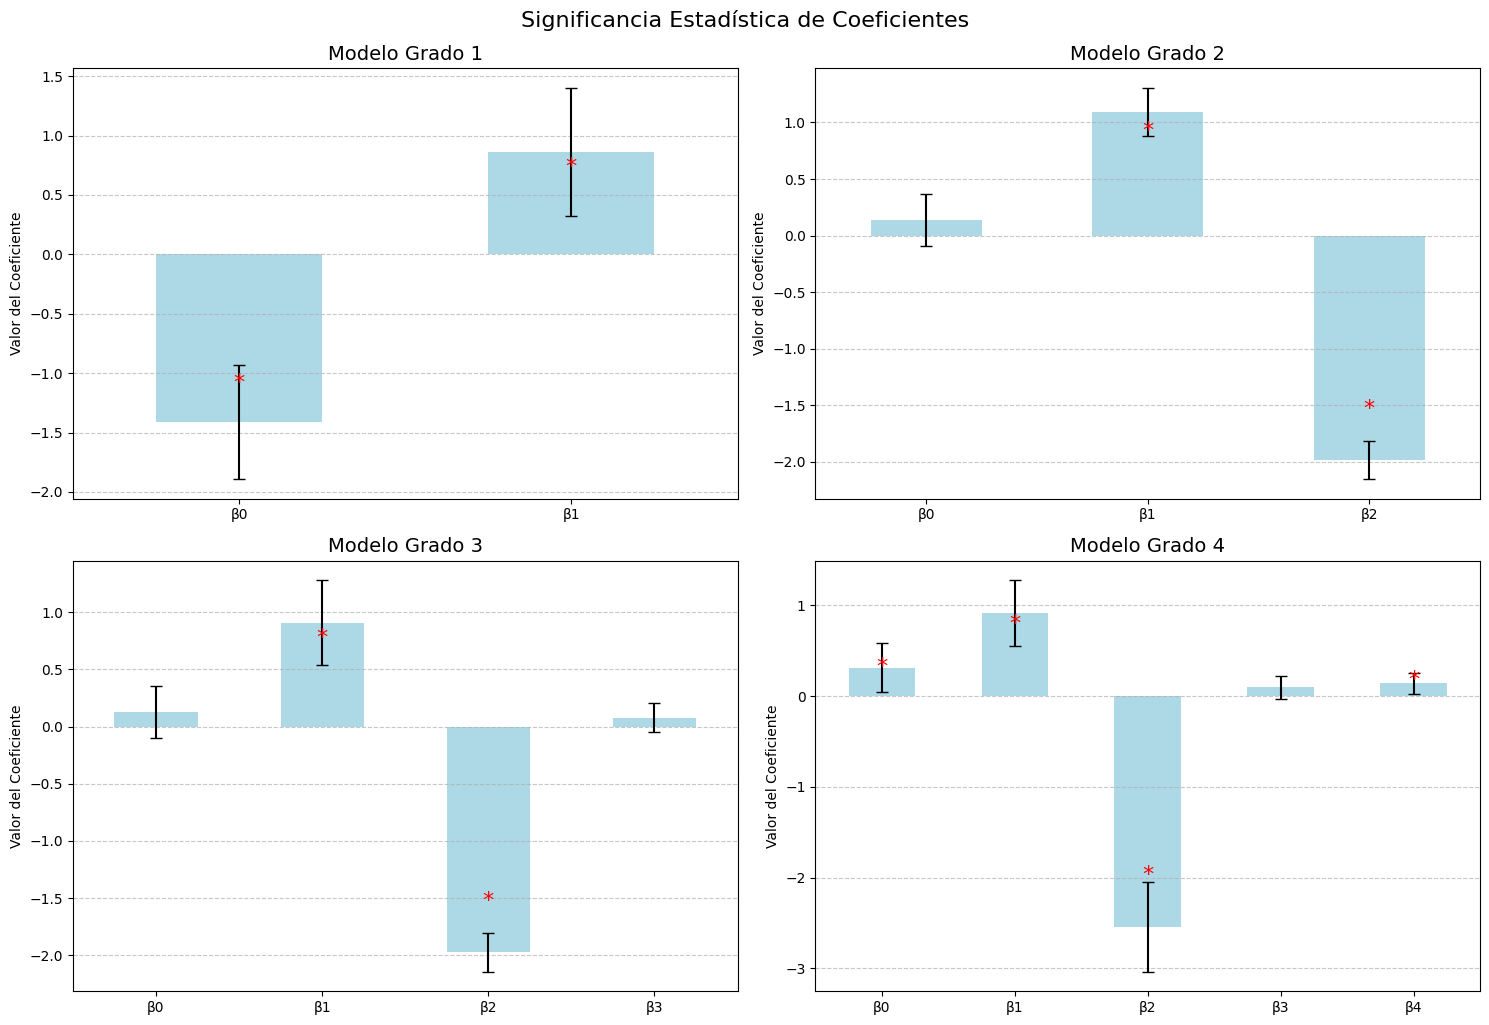

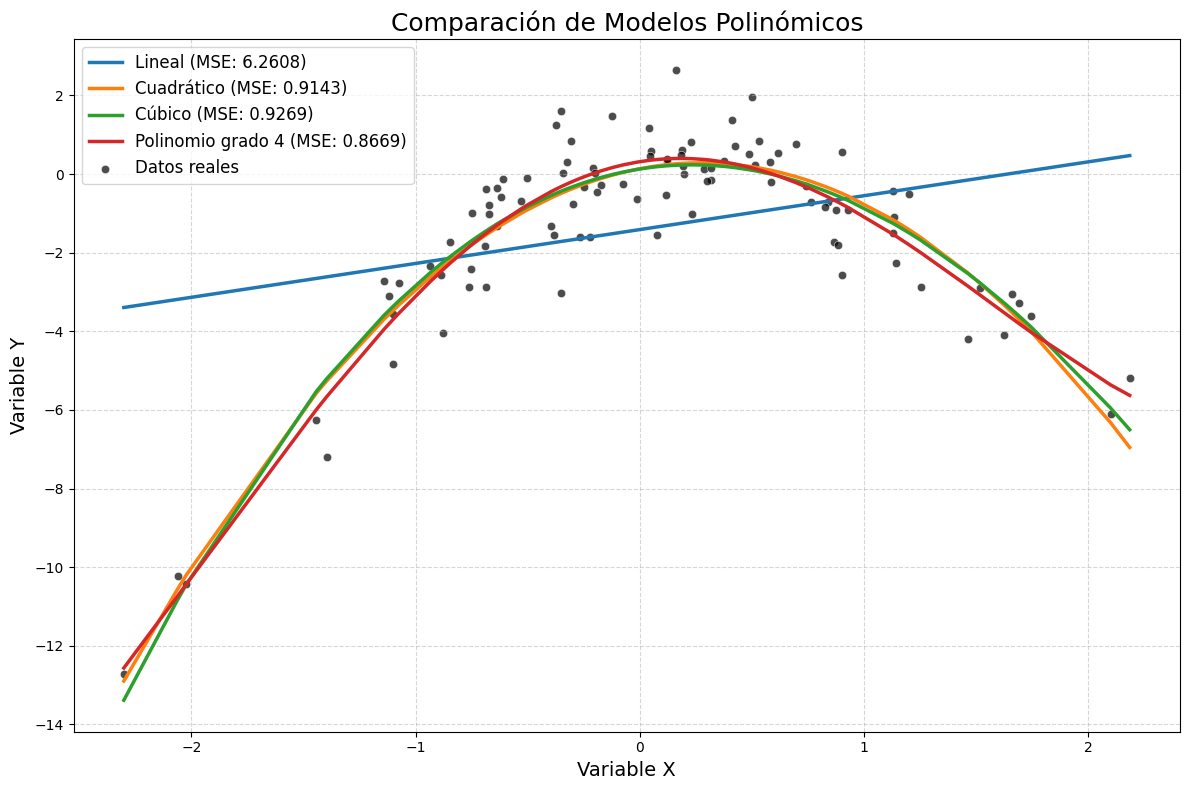


Resumen final:
- El diagrama de dispersión muestra una relación cuadrática clara
- El modelo cuadrático tiene el menor error LOOCV en ambas semillas
- Los coeficientes del modelo cuadrático son estadísticamente significativos
- Modelos de mayor grado muestran signos de sobreajuste (coeficientes no significativos)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm


#  Generacion de datos simulados

np.random.seed(1)
x = np.random.normal(size=100)
y = x - 2*x**2 + np.random.normal(size=100)
data = pd.DataFrame({'x': x, 'y': y})


#  análisis del conjunto de datos

print("\n[b] Análisis del conjunto de datos:")
print(f"- n (número de observaciones): {len(data)}")
print(f"- p (número de predictores): 1 (variable x)")
print("Modelo generador: y = x - 2x² + ε, donde ε ~ N(0, 1)")


#  diagrama de dispersión

plt.figure(figsize=(10, 6))
sns.scatterplot(x='x', y='y', data=data, alpha=0.7, color='blue')
plt.title('Diagrama de Dispersión: X vs Y', fontsize=16)
plt.xlabel('Variable X', fontsize=12)
plt.ylabel('Variable Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('dispersion_xy.png', dpi=300)
plt.show()


print("Se observa una clara relación cuadrática entre X e Y. Los datos siguen una forma parabólica")
print("cóncava hacia abajo, con un máximo cerca de x = 0. Esto es consistente con el modelo generador")
print("y = x - 2x² + ε. La dispersión de los puntos alrededor de la curva sugiere la presencia de")
print("ruido gaussiano en los datos.")


#  Calculo de errores LOOCV para cuatro modelos

models = [
    {'name': 'Lineal', 'degree': 1},
    {'name': 'Cuadrático', 'degree': 2},
    {'name': 'Cúbico', 'degree': 3},
    {'name': 'Polinomio grado 4', 'degree': 4}
]

loocv = LeaveOneOut()
results = {}
model_predictions = {model['name']: [] for model in models}

for model in models:
    mse_scores = []
    degree = model['degree']

    for train_idx, test_idx in loocv.split(data):
        X_train = data.iloc[train_idx][['x']]
        y_train = data.iloc[train_idx]['y']
        X_test = data.iloc[test_idx][['x']]
        y_test = data.iloc[test_idx]['y']

        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_lr = LinearRegression()
        model_lr.fit(X_train_poly, y_train)

        y_pred = model_lr.predict(X_test_poly)
        mse = mean_squared_error(y_test, y_pred)
        mse_scores.append(mse)

        # Guardar predicción para gráfico
        model_predictions[model['name']].append(y_pred[0])

    mean_mse = np.mean(mse_scores)
    results[model['name']] = mean_mse

print("\n[d] Resultados LOOCV (Semilla 1):")
for model_name, mse in results.items():
    print(f"{model_name}: MSE = {mse:.4f}")

# Diagrama de comparación de modelos
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Comparación de Errores LOOCV por Modelo', fontsize=16)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('comparacion_loocv.png', dpi=300)
plt.show()


np.random.seed(42)
x_new = np.random.normal(size=100)
y_new = x_new - 2*x_new**2 + np.random.normal(size=100)
data_new = pd.DataFrame({'x': x_new, 'y': y_new})

results_new = {}

for model in models:
    mse_scores = []
    degree = model['degree']

    for train_idx, test_idx in loocv.split(data_new):
        X_train = data_new.iloc[train_idx][['x']]
        y_train = data_new.iloc[train_idx]['y']
        X_test = data_new.iloc[test_idx][['x']]
        y_test = data_new.iloc[test_idx]['y']

        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_lr = LinearRegression()
        model_lr.fit(X_train_poly, y_train)

        y_pred = model_lr.predict(X_test_poly)
        mse = mean_squared_error(y_test, y_pred)
        mse_scores.append(mse)

    mean_mse = np.mean(mse_scores)
    results_new[model['name']] = mean_mse

print("\n[e] Resultados LOOCV (Semilla 42):")
for model_name, mse in results_new.items():
    print(f"{model_name}: MSE = {mse:.4f}")

# Comparación de resultados con diagrama
plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
width = 0.35
x_pos = np.arange(len(models))

rects1 = ax.bar(x_pos - width/2, [results[m['name']] for m in models],
                width, label='Semilla 1', color='skyblue')
rects2 = ax.bar(x_pos + width/2, [results_new[m['name']] for m in models],
                width, label='Semilla 42', color='salmon')

ax.set_title('Comparación de Errores LOOCV con Diferentes Semillas', fontsize=16)
ax.set_ylabel('MSE', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels([m['name'] for m in models])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('comparacion_semillas.png', dpi=300)
plt.show()

#  Análisis del mejor modelo

best_model = min(results, key=results.get)
best_mse = results[best_model]

print(f"\n[f] Modelo con menor error LOOCV: {best_model} (MSE = {best_mse:.4f})")
print("¿Es esto lo que esperabas? Sí, porque el modelo generador es cuadrático (y = x - 2x² + ε)")
print("El modelo cuadrático captura exactamente la relación subyacente en los datos.")


#  Significancia estadística de coeficientes

print("\n[g] Significancia estadística de coeficientes:")

# Crear figura para coeficientes
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, degree in enumerate([1, 2, 3, 4]):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(data[['x']])

    X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['x']))
    model_sm = sm.OLS(data['y'], X_poly_df).fit()

    # Gráfico de coeficientes con intervalos de confianza
    coefs = model_sm.params
    conf_int = model_sm.conf_int()

    ax = axes[i]
    coefs.plot.bar(yerr=[coefs - conf_int[0]], capsize=4, ax=ax, color='lightblue')
    ax.set_title(f'Modelo Grado {degree}', fontsize=14)
    ax.set_ylabel('Valor del Coeficiente', fontsize=10)
    ax.set_xticklabels([f'β{j}' for j in range(degree+1)], rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Destacar coeficientes significativos
    for j, pval in enumerate(model_sm.pvalues):
        if pval < 0.05:
            ax.text(j, coefs[j]*0.8, '*', fontsize=16, ha='center', color='red')

    print(f"\nModelo polinómico grado {degree}:")
    print(model_sm.summary().tables[1])

plt.tight_layout()
plt.suptitle('Significancia Estadística de Coeficientes', fontsize=16, y=1.02)
plt.savefig('significancia_coeficientes.png', dpi=300)
plt.show()

# Diagrama de comparación de modelos
plt.figure(figsize=(12, 8))
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]

# Ajustar modelos completos para visualización
for model in models:
    degree = model['degree']
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(data[['x']])

    model_lr = LinearRegression()
    model_lr.fit(X_poly, data['y'])

    X_sorted_poly = poly.transform(pd.DataFrame({'x': x_sorted}))
    y_pred = model_lr.predict(X_sorted_poly)

    plt.plot(x_sorted, y_pred, linewidth=2.5,
             label=f'{model["name"]} (MSE: {results[model["name"]]:.4f})')

# Datos reales
sns.scatterplot(x='x', y='y', data=data, alpha=0.7, color='black', label='Datos reales')

plt.title('Comparación de Modelos Polinómicos', fontsize=18)
plt.xlabel('Variable X', fontsize=14)
plt.ylabel('Variable Y', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=300)
plt.show()

print("- El diagrama de dispersión muestra una relación cuadrática clara")
print("- El modelo cuadrático tiene el menor error LOOCV en ambas semillas")
print("- Los coeficientes del modelo cuadrático son estadísticamente significativos")
print("- Modelos de mayor grado muestran signos de sobreajuste (coeficientes no significativos)")

2.- Aplicar algún enfoque de selección (exclusivamente step by step o stepwise,
forward o backward) del mejor subconjunto a los datos de bateadores (archivo
Hitters.csv). Queremos predecir el salario de un jugador de béisbol con base en
diversas estadísticas asociadas con su rendimiento del año anterior.



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Cargar datos y preprocesar
hitters = pd.read_csv('HITTERRS.csv').dropna()
y = hitters['Salary']
X_raw = hitters.drop(columns=['Salary'])

# Codificar variables categóricas
X = pd.get_dummies(X_raw, drop_first=True)


lr = LinearRegression()

# Forward Stepwise
sfs_forward = SFS(lr, k_features='best', forward=True, floating=False, scoring='r2', cv=5)
sfs_forward.fit(X, y)
print('Variables seleccionadas (Forward):', sfs_forward.k_feature_names_)



# Backward Stepwise
sfs_backward = SFS(lr, k_features='best', forward=False, floating=False, scoring='r2', cv=5)
sfs_backward.fit(X, y)
print('Variables seleccionadas (Backward):', sfs_backward.k_feature_names_)


Variables seleccionadas (Forward): ('Walks', 'CRuns', 'CWalks', 'Division_W')
Variables seleccionadas (Backward): ('AtBat', 'Hits', 'Walks', 'CRBI', 'PutOuts', 'Division_W')


3.- Considerando la base de datos del inciso anterior. Elija entre modelos mediante los enfoques de: conjunto de validación y de validación cruzada ( y, discutir si hay alguno que es más preponderante).


R2 Test (Validation Set): 0.3733488560057836
R2 CV (10-fold): 0.32457135222462724


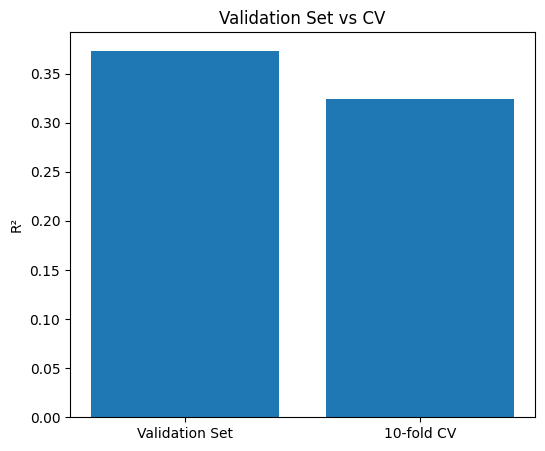

In [ ]:
# División en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Modelo con conjunto de validación
lr.fit(X_train, y_train)
print('R2 Test (Validation Set):', lr.score(X_test, y_test))

# Validación cruzada (10-fold CV)
scores_cv = cross_val_score(lr, X, y, cv=10, scoring='r2')
print('R2 CV (10-fold):', scores_cv.mean())

# Gráfico comparativo
plt.figure(figsize=(6,5))
plt.bar(['Validation Set','10‑fold CV'], [r2_test, r2_cv])
plt.ylabel('R²')
plt.title('Validation Set vs CV')
plt.show()

4.- Ahora realice una regresión de cresta y una regresión Lasso para predecir el salario en los datos de los bateadores (discutir cual fue mejor, si la hubiese).


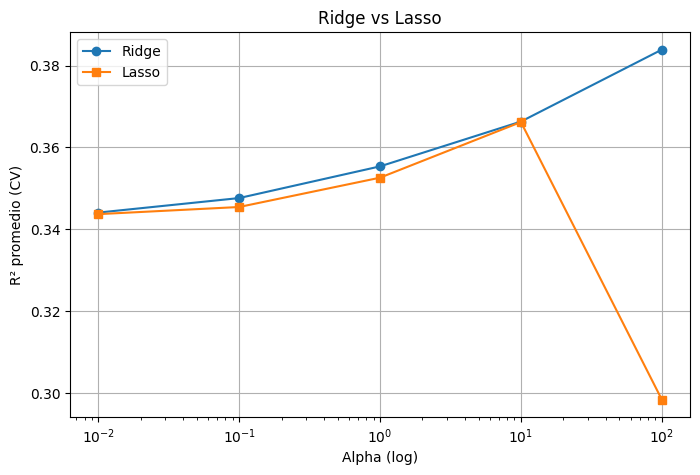

In [ ]:
alphas = [0.01,0.1,1,10,100]
ridge_scores, lasso_scores = [], []
for a in alphas:
    r = Pipeline([('s',StandardScaler()),('m',Ridge(alpha=a))])
    l = Pipeline([('s',StandardScaler()),('m',Lasso(alpha=a, max_iter=10000))])
    ridge_scores.append(cross_val_score(r,X,y,cv=5,scoring='r2').mean())
    lasso_scores.append(cross_val_score(l,X,y,cv=5,scoring='r2').mean())

# Gráfico Ridge vs Lasso
plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_scores, marker='o', label='Ridge')
plt.plot(alphas, lasso_scores, marker='s', label='Lasso')
plt.xscale('log')
plt.xlabel('Alpha (log)')
plt.ylabel('R² promedio (CV)')
plt.title('Ridge vs Lasso')
plt.legend()
plt.grid(True)
plt.show()

5.- Ahora para el mismo conjunto de datos, aplicar PCR a los datos de los bateadores para predecir el salario.

Mejor PCR: 1 componentes, R² = 0.3714


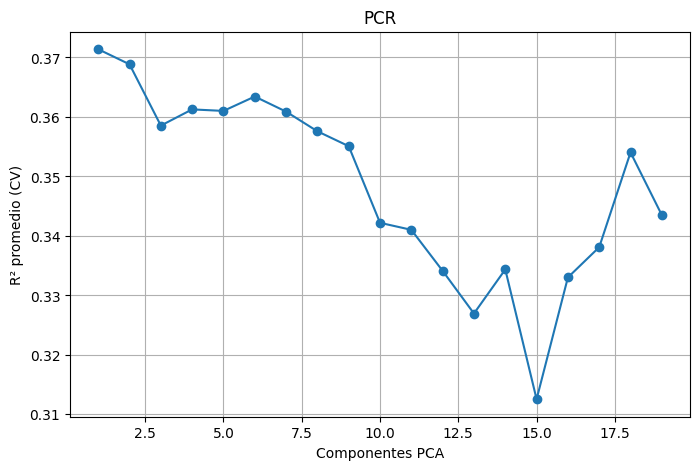

In [ ]:
r2_pcr = []
for n in range(1, X.shape[1]+1):
    pcr = make_pipeline(StandardScaler(), PCA(n_components=n), LinearRegression())
    r2_pcr.append(cross_val_score(pcr,X,y,cv=5,scoring='r2').mean())
best_n = r2_pcr.index(max(r2_pcr))+1
print(f'Mejor PCR: {best_n} componentes, R² = {max(r2_pcr):.4f}')

# Gráfico PCR
plt.figure(figsize=(8,5))
plt.plot(range(1,X.shape[1]+1), r2_pcr, marker='o')
plt.xlabel('Componentes PCA')
plt.ylabel('R² promedio (CV)')
plt.title('PCR')
plt.grid(True)
plt.show()

6.- Finalmente, implementar mínimos cuadrados parciales (PLS)


Mejor PLS: 1 componentes, R² = 0.3792


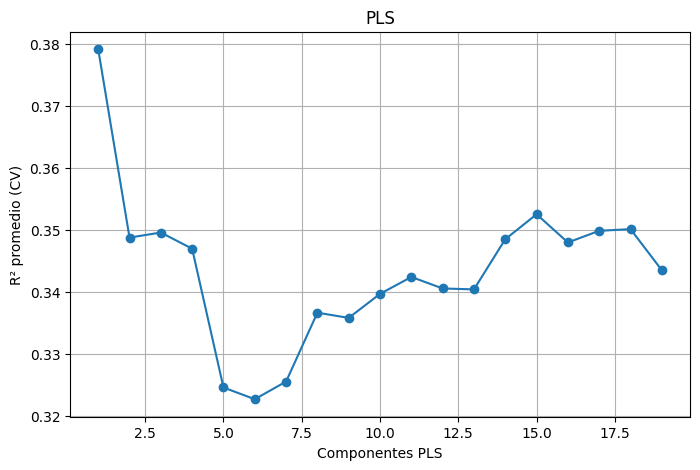

In [ ]:
r2_pls = []
for n in range(1,X.shape[1]+1):
    model = make_pipeline(StandardScaler(), PLSRegression(n_components=n))
    r2_pls.append(cross_val_score(model,X,y,cv=5,scoring='r2').mean())
best_n_pls = r2_pls.index(max(r2_pls))+1
print(f'Mejor PLS: {best_n_pls} componentes, R² = {max(r2_pls):.4f}')

# Gráfico PLS
plt.figure(figsize=(8,5))
plt.plot(range(1,X.shape[1]+1), r2_pls, marker='o')
plt.xlabel('Componentes PLS')
plt.ylabel('R² promedio (CV)')
plt.title('PLS')
plt.grid(True)
plt.show()

7.- Discutir, cual metodología, de los puntos: 2, 3, 5 y 6 resulto más adecuada, si la hubiese (cuándo y por qué aplicar una u otra o si hay un modelo metodológico ideal)
